# J03 — Courbe de rétention, hystérésis et fonctions de pédotransfert

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 3 : ajustement VG/BC, points remarquables et réserve utile, pédotransfert, hystérésis*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les données sont dans `data/`. Unités du cours : $h$ en cm (négatif en non saturé), $\theta$ en m³/m³, $K_s$ en cm/j.
Les sols de référence sont ceux de Carsel & Parrish (1988).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, special

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})

# Carsel & Parrish (1988) : θr, θs, α (1/cm), n, Ks (cm/j)
CP = {"sable": (0.045, 0.43, 0.145, 2.68, 712.8), "loam sableux": (0.065, 0.41, 0.075, 1.89, 106.1),
      "loam": (0.078, 0.43, 0.036, 1.56, 24.96), "loam limoneux": (0.067, 0.45, 0.020, 1.41, 10.8),
      "loam argileux": (0.095, 0.41, 0.019, 1.31, 6.24), "argile": (0.068, 0.38, 0.008, 1.09, 4.8)}

def vg(h, tr, ts, a, n):
    """van Genuchten (1980) : θ(h), m = 1 - 1/n."""
    m = 1 - 1 / n
    return tr + (ts - tr) * (1 + (a * np.abs(h)) ** n) ** (-m)

def vg_C(h, tr, ts, a, n):
    """Capacité capillaire C(h) = dθ/dh (1/cm) du modèle de van Genuchten."""
    m = 1 - 1 / n
    ah = a * np.abs(h)
    return (ts - tr) * a * n * m * ah ** (n - 1) * (1 + ah ** n) ** (-m - 1)

def bc(h, tr, ts, hb, lam):
    """Brooks & Corey (1964) : θ(h) avec pression d'entrée d'air hb (> 0, cm) et indice λ."""
    h = np.abs(h)
    return np.where(h <= hb, ts, tr + (ts - tr) * (hb / h) ** lam)

## Exercice 1 — Ajustement des modèles de van Genuchten et de Brooks–Corey  *(≈ 20 min)*

`data/J03_retention_mesures.csv` : couples $(h, \theta)$ mesurés en drainage (9 points, bruit expérimental) sur un sable, un loam
et une argile.

1. Pour chaque sol, ajuster le modèle de van Genuchten ($\theta_r$, $\theta_s$, $\alpha$, $n$) et celui de Brooks–Corey
   ($\theta_r$, $\theta_s$, $h_b$, $\lambda$) avec `scipy.optimize.curve_fit`, en imposant des bornes physiques
   ($0 \le \theta_r \le 0{,}25$, $0{,}3 \le \theta_s \le 0{,}6$, $10^{-4} \le \alpha \le 1$, $1{,}05 \le n \le 8$ ;
   $1 \le h_b \le 500$, $0{,}05 \le \lambda \le 3$) et une initialisation raisonnable.
2. Calculer le RMSE et le $R^2$ de chaque ajustement ; présenter un tableau (paramètres, RMSE, $R^2$) et le comparer aux
   paramètres de Carsel & Parrish (dictionnaire `CP`).
3. Tracer, pour les trois sols, les points mesurés et les deux modèles ($|h|$ en échelle log), puis la capacité capillaire $C(h)$
   du modèle VG (échelle log–log).
4. Extraire de la matrice de covariance les écarts-types des paramètres VG et la corrélation entre $\alpha$ et $n$.

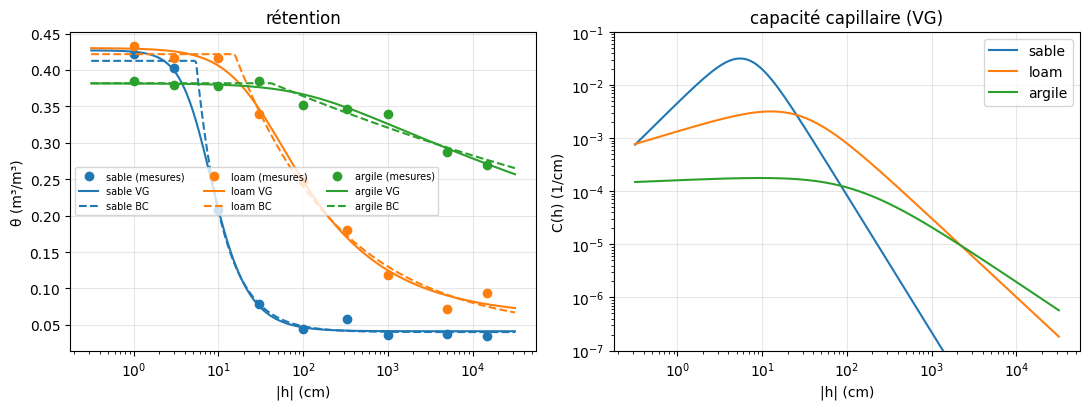

,sol,modèle,θr,θs,α (1/cm) | hb (cm),n | λ,RMSE,R²
0,sable,VG,0.0412,0.4269,0.1509,2.5792,0.0066,0.9981
1,sable,BC,0.0400,0.4125,5.4408,1.3167,0.0079,0.9973
2,loam,VG,0.0611,0.4301,0.0372,1.4848,0.0103,0.9945
3,loam,BC,0.0396,0.4217,15.6182,0.3465,0.0113,0.9934
4,argile,VG,0.0000,0.3816,0.0084,1.0709,0.0074,0.9658
5,argile,BC,0.0000,0.3818,42.3878,0.0551,0.0084,0.9564


Paramètres de Carsel & Parrish (référence) :


,θr,θs,α,n
sable,0.045,0.43,0.145,2.68
loam,0.078,0.43,0.036,1.56
argile,0.068,0.38,0.008,1.09


sable   : α = 0.1509 ± 0.0147, n = 2.579 ± 0.226, corr(α, n) = -0.85
loam    : α = 0.0372 ± 0.0107, n = 1.485 ± 0.112, corr(α, n) = -0.82
argile  : α = 0.0084 ± 0.0118, n = 1.071 ± 0.315, corr(α, n) = -0.87


In [2]:
mes = pd.read_csv("data/J03_retention_mesures.csv")
hh = -np.logspace(-0.5, 4.5, 300)

def rmse_r2(y, yhat):
    res = y - yhat
    return np.sqrt(np.mean(res**2)), 1 - np.sum(res**2) / np.sum((y - y.mean())**2)

fits, rows = {}, []
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for sol, g in mes.groupby("sol", sort=False):
    h, th = g["h_cm"].to_numpy(), g["theta"].to_numpy()
    p_vg, cov_vg = optimize.curve_fit(vg, h, th, p0=[0.05, 0.45, 0.02, 1.5],
                                      bounds=([0, 0.3, 1e-4, 1.05], [0.25, 0.6, 1, 8]))
    p_bc, cov_bc = optimize.curve_fit(bc, h, th, p0=[0.05, 0.45, 20, 0.5],
                                      bounds=([0, 0.3, 1, 0.05], [0.25, 0.6, 500, 3]))
    fits[sol] = dict(vg=p_vg, bc=p_bc, cov_vg=cov_vg)
    for nom, f, p in [("VG", vg, p_vg), ("BC", bc, p_bc)]:
        r, r2 = rmse_r2(th, f(h, *p))
        rows.append(dict(sol=sol, modele=nom, p1=p[0], p2=p[1], p3=p[2], p4=p[3], RMSE=r, R2=r2))
    l, = ax[0].semilogx(-h, th, "o", label=f"{sol} (mesures)")
    ax[0].semilogx(-hh, vg(hh, *p_vg), "-", color=l.get_color(), label=f"{sol} VG")
    ax[0].semilogx(-hh, bc(hh, *p_bc), "--", color=l.get_color(), label=f"{sol} BC")
    ax[1].loglog(-hh, vg_C(hh, *p_vg), color=l.get_color(), label=sol)
ax[0].set_xlabel("|h| (cm)"); ax[0].set_ylabel("θ (m³/m³)"); ax[0].legend(fontsize=7, ncol=3); ax[0].set_title("rétention")
ax[1].set_xlabel("|h| (cm)"); ax[1].set_ylabel("C(h) (1/cm)"); ax[1].set_ylim(1e-7, 1e-1); ax[1].legend(); ax[1].set_title("capacité capillaire (VG)")
plt.tight_layout(); plt.show()

tab = pd.DataFrame(rows)
tab.columns = ["sol", "modèle", "θr", "θs", "α (1/cm) | hb (cm)", "n | λ", "RMSE", "R²"]
display(tab.round(4))
cp = pd.DataFrame({s: CP[s][:4] for s in ["sable", "loam", "argile"]}, index=["θr", "θs", "α", "n"]).T
print("Paramètres de Carsel & Parrish (référence) :"); display(cp)

# 4. incertitudes et corrélation α–n (VG)
for sol, f in fits.items():
    err = np.sqrt(np.diag(f["cov_vg"])); corr = f["cov_vg"] / np.outer(err, err)
    print(f"{sol:7s} : α = {f['vg'][2]:.4f} ± {err[2]:.4f}, n = {f['vg'][3]:.3f} ± {err[3]:.3f}, corr(α, n) = {corr[2, 3]:+.2f}")

**Commentaire (instructeur).** Les deux modèles reproduisent les données à ~0,005–0,01 près (l'ordre du bruit) ; VG est légèrement meilleur pour le loam et
l'argile, BC pour le sable (chute brutale). Les paramètres VG retrouvés sont proches de Carsel & Parrish, sauf $\theta_r$ et $n$
de l'argile, mal contraints (courbe presque plate : $n \to 1$, forte incertitude). La corrélation négative entre $\alpha$ et $n$
(−0,6 à −0,9) montre que ces deux paramètres se compensent : c'est un problème d'identifiabilité classique (Jour 10).

## Exercice 2 — Points remarquables, réserve utile et réserve facilement utilisable  *(≈ 10 min)*

Avec les paramètres VG ajustés à l'exercice 1 :

1. Calculer $\theta$ à $-100$, $-330$ et $-15\,000$ cm pour chaque sol ; en déduire la réserve utile par mètre de sol,
   $\mathrm{RU} = (\theta_{cc} - \theta_{pf}) \times 1000$ mm, selon les deux conventions de capacité au champ ($-100$ et $-330$ cm).
2. Pour un enracinement $Z = 60$ cm et $p = 0{,}5$, calculer la RFU (mm) et le nombre de jours d'autonomie sans pluie pour
   $\mathrm{ET}_c = 5$ mm/j (convention $-330$ cm pour le loam et l'argile, $-100$ cm pour le sable).
3. Représenter en barres $\theta_{-100}$, $\theta_{-330}$, $\theta_{-15000}$ et $\theta_s$ pour les trois sols.

,theta_s,theta_100,theta_330,theta_15000,RU100_mm_m,RU330_mm_m,RFU_60cm_mm,autonomie_j
sol,,,,,,,,
sable,0.427,0.047,0.042,0.041,5.303,0.804,1.591,0.318
loam,0.430,0.248,0.170,0.078,169.664,91.347,27.404,5.481
argile,0.382,0.367,0.348,0.271,95.893,77.509,23.253,4.651


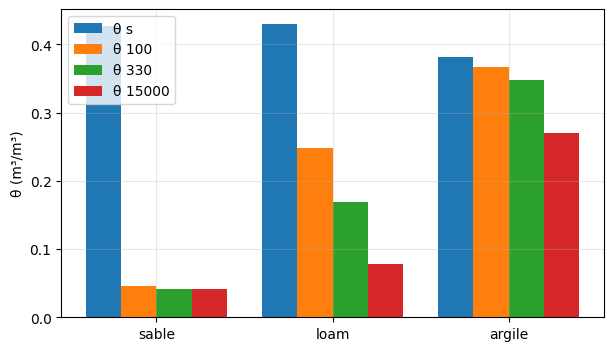

In [3]:
rows = []
for sol, f in fits.items():
    p = f["vg"]
    t100, t330, tpf = vg(-100, *p), vg(-330, *p), vg(-15000, *p)
    ru100, ru330 = (t100 - tpf) * 1000, (t330 - tpf) * 1000          # mm par m de sol
    ru_conv = ru100 if sol == "sable" else ru330                      # convention selon la texture
    rfu = 0.5 * ru_conv * 0.6                                          # mm sur 60 cm
    rows.append(dict(sol=sol, theta_s=p[1], theta_100=t100, theta_330=t330, theta_15000=tpf,
                     RU100_mm_m=ru100, RU330_mm_m=ru330, RFU_60cm_mm=rfu, autonomie_j=rfu / 5))
pts = pd.DataFrame(rows).set_index("sol")
display(pts.round(3))

fig, ax = plt.subplots()
x = np.arange(len(pts)); w = 0.2
for k, col in enumerate(["theta_s", "theta_100", "theta_330", "theta_15000"]):
    ax.bar(x + (k - 1.5) * w, pts[col], w, label=col.replace("theta_", "θ "))
ax.set_xticks(x); ax.set_xticklabels(pts.index); ax.set_ylabel("θ (m³/m³)"); ax.legend(); plt.show()

**Commentaire (instructeur).** Le sable de Carsel & Parrish ne retient presque rien au-delà de −100 cm : RU de quelques mm/m, autonomie inférieure à un jour
(irréaliste pour un sable fin réel, plutôt 50–70 mm/m). Le loam donne ≈ 90 mm/m (convention −330) ou ≈ 170 mm/m (convention −100)
avec les paramètres ajustés, contre 77 et 154 mm/m avec ceux de Carsel & Parrish (diapositives) : le choix de la convention pèse
autant que la précision de l'ajustement. L'argile a une RU comparable au loam malgré une forte
$\theta_{cc}$, parce que $\theta_{pf}$ est élevée (eau retenue dans les pores les plus fins, inaccessible).

## Exercice 3 — Fonctions de pédotransfert : Saxton & Rawls vs Carsel & Parrish vs Rosetta  *(≈ 20 min)*

1. Implémenter `saxton_rawls(S, C, OM)` (S = sable et C = argile en fractions 0–1, OM en % masse) selon Saxton & Rawls (2006) :

   $\theta_{1500}^t = -0{,}024S + 0{,}487C + 0{,}006\,OM + 0{,}005\,S\,OM - 0{,}013\,C\,OM + 0{,}068\,SC + 0{,}031$ ;
   $\theta_{1500} = \theta_{1500}^t + (0{,}14\,\theta_{1500}^t - 0{,}02)$

   $\theta_{33}^t = -0{,}251S + 0{,}195C + 0{,}011\,OM + 0{,}006\,S\,OM - 0{,}027\,C\,OM + 0{,}452\,SC + 0{,}299$ ;
   $\theta_{33} = \theta_{33}^t + (1{,}283\,(\theta_{33}^t)^2 - 0{,}374\,\theta_{33}^t - 0{,}015)$

   $\theta_{S-33}^t = 0{,}278S + 0{,}034C + 0{,}022\,OM - 0{,}018\,S\,OM - 0{,}027\,C\,OM - 0{,}584\,SC + 0{,}078$ ;
   $\theta_{S-33} = \theta_{S-33}^t + (0{,}636\,\theta_{S-33}^t - 0{,}107)$

   $\theta_s = \theta_{33} + \theta_{S-33} - 0{,}097S + 0{,}043$ ; $\lambda = (\ln\theta_{33} - \ln\theta_{1500})/(\ln 1500 - \ln 33)$ ;
   $K_s\,[\mathrm{mm/h}] = 1930\,(\theta_s - \theta_{33})^{3-\lambda}$ ;

   pression d'entrée d'air (kPa) : $\psi_e^t = -21{,}67S - 27{,}93C - 81{,}97\,\theta_{S-33} + 71{,}12\,S\,\theta_{S-33} + 8{,}29\,C\,\theta_{S-33} + 14{,}05\,SC + 27{,}16$,
   $\psi_e = \psi_e^t + (0{,}02\,(\psi_e^t)^2 - 0{,}113\,\psi_e^t - 0{,}70)$.

   La courbe complète est : $\theta = \theta_s$ pour $\psi < \psi_e$ ; linéaire entre $(\psi_e, \theta_s)$ et $(33, \theta_{33})$ ;
   $\psi = A\,\theta^{-B}$ au-delà de 33 kPa, avec $B = 1/\lambda$ et $A = \exp(\ln 33 + B\ln\theta_{33})$.
2. `data/J03_textures.csv` (six sols A–F, texture, MO, $\rho_b$, classe USDA) : calculer les prédictions de Saxton–Rawls
   et les comparer, pour chaque sol, à $\theta(-330)$, $\theta(-15000)$ et $K_s$ (i) des paramètres de Carsel & Parrish de la classe
   et (ii) des paramètres Rosetta fournis dans `data/J03_rosetta_H3.csv`. Tableau récapitulatif.
3. Tracer $\theta(h)$ des trois sources pour les sols C (loam) et F (argile). Calculer, pour chaque sol, l'écart type entre les trois
   sources de la RU (mm/m) et de $\log_{10} K_s$ : quelle grandeur est la plus incertaine ?

,classe,θ33 SR,θ33 CP,θ33 Ros,θ1500 SR,θ1500 CP,θ1500 Ros,Ks SR,Ks CP,Ks Ros
sol,,,,,,,,,,
A,sable,0.055,0.046,0.055,0.015,0.045,0.053,335.489,712.80,642.98
B,loam sableux,0.165,0.084,0.176,0.072,0.066,0.064,107.264,106.10,38.25
C,loam,0.280,0.164,0.253,0.137,0.088,0.094,37.142,24.96,12.04
D,loam limoneux,0.311,0.239,0.309,0.113,0.104,0.087,46.123,10.80,18.26
E,loam argileux,0.354,0.269,0.267,0.213,0.149,0.119,11.339,6.24,8.18
F,argile,0.441,0.347,0.354,0.323,0.270,0.198,2.167,4.80,14.75


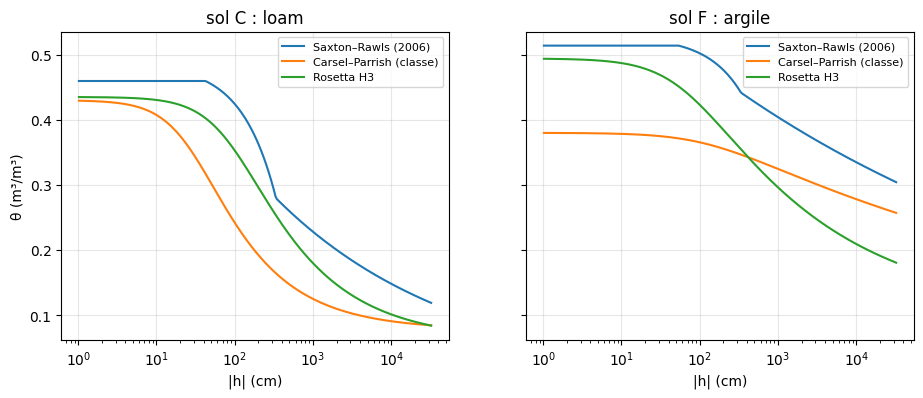

,RU moyenne (mm/m),écart type RU (mm/m),CV RU (%),log10 Ks moyen,écart type log10 Ks,facteur sur Ks
sol,,,,,,
A,14.24,22.86,160.55,2.73,0.18,1.50
B,74.64,49.24,65.97,1.88,0.26,1.81
C,125.93,43.93,34.88,1.35,0.25,1.77
D,185.03,44.68,24.15,1.32,0.32,2.09
E,136.46,15.22,11.16,0.92,0.13,1.35
F,116.87,40.04,34.26,0.73,0.42,2.62


In [4]:
def saxton_rawls(S, C, OM):
    """Saxton & Rawls (2006). S, C : fractions (0-1) ; OM : % masse. θ en m³/m³, Ks en cm/j, ψe en kPa."""
    t1500t = -0.024*S + 0.487*C + 0.006*OM + 0.005*S*OM - 0.013*C*OM + 0.068*S*C + 0.031
    t1500 = t1500t + (0.14*t1500t - 0.02)
    t33t = -0.251*S + 0.195*C + 0.011*OM + 0.006*S*OM - 0.027*C*OM + 0.452*S*C + 0.299
    t33 = t33t + (1.283*t33t**2 - 0.374*t33t - 0.015)
    tS33t = 0.278*S + 0.034*C + 0.022*OM - 0.018*S*OM - 0.027*C*OM - 0.584*S*C + 0.078
    tS33 = tS33t + (0.636*tS33t - 0.107)
    tS = t33 + tS33 - 0.097*S + 0.043
    lam = (np.log(t33) - np.log(t1500)) / (np.log(1500) - np.log(33))
    Ks_mmh = 1930 * (tS - t33) ** (3 - lam)
    psiet = -21.67*S - 27.93*C - 81.97*tS33 + 71.12*S*tS33 + 8.29*C*tS33 + 14.05*S*C + 27.16
    psie = psiet + (0.02*psiet**2 - 0.113*psiet - 0.70)
    return dict(theta_1500=t1500, theta_33=t33, theta_s=tS, lam=lam, Ks_cmj=Ks_mmh * 2.4, psi_e_kPa=max(psie, 0.5))

def theta_sr(psi_kPa, p):
    """Courbe θ(ψ) de Saxton-Rawls (ψ > 0 en kPa)."""
    psi = np.asarray(psi_kPa, float)
    B = 1 / p["lam"]; A = np.exp(np.log(33) + B * np.log(p["theta_33"]))
    th_pow = (psi / A) ** (-1 / B)
    th_lin = p["theta_33"] + (33 - psi) * (p["theta_s"] - p["theta_33"]) / (33 - p["psi_e_kPa"])
    return np.where(psi >= 33, th_pow, np.where(psi >= p["psi_e_kPa"], th_lin, p["theta_s"]))

tex = pd.read_csv("data/J03_textures.csv")
ros = pd.read_csv("data/J03_rosetta_H3.csv").set_index("sol")
KPA = 1e3 / (998.2 * 9.81) * 100        # cm par kPa

rows, sr_all = [], {}
for _, r in tex.iterrows():
    sr = saxton_rawls(r["sable_pct"] / 100, r["argile_pct"] / 100, r["MO_pct"]); sr_all[r["sol"]] = sr
    cpp = CP[r["classe_USDA"]]
    rp = ros.loc[r["sol"]]
    rows.append({"sol": r["sol"], "classe": r["classe_USDA"],
                 "θ33 SR": sr["theta_33"], "θ33 CP": vg(-33 * KPA, *cpp[:4]), "θ33 Ros": vg(-33 * KPA, rp["theta_r"], rp["theta_s"], rp["alpha_1cm"], rp["n"]),
                 "θ1500 SR": sr["theta_1500"], "θ1500 CP": vg(-1500 * KPA, *cpp[:4]), "θ1500 Ros": vg(-1500 * KPA, rp["theta_r"], rp["theta_s"], rp["alpha_1cm"], rp["n"]),
                 "Ks SR": sr["Ks_cmj"], "Ks CP": cpp[4], "Ks Ros": rp["Ks_cmj"]})
comp = pd.DataFrame(rows).set_index("sol")
display(comp.round(3))

# 3. courbes θ(h) des trois sources pour C (loam) et F (argile)
psi = np.logspace(-1, 3.5, 300)                       # kPa
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for a, sol in zip(ax, ["C", "F"]):
    r = tex.set_index("sol").loc[sol]; cpp = CP[r["classe_USDA"]]; rp = ros.loc[sol]
    a.semilogx(psi * KPA, theta_sr(psi, sr_all[sol]), label="Saxton–Rawls (2006)")
    a.semilogx(psi * KPA, vg(-psi * KPA, *cpp[:4]), label="Carsel–Parrish (classe)")
    a.semilogx(psi * KPA, vg(-psi * KPA, rp["theta_r"], rp["theta_s"], rp["alpha_1cm"], rp["n"]), label="Rosetta H3")
    a.set_title(f"sol {sol} : {r['classe_USDA']}"); a.set_xlabel("|h| (cm)"); a.legend(fontsize=8)
ax[0].set_ylabel("θ (m³/m³)"); plt.show()

# écart type entre sources : RU (mm/m) et log10 Ks
ru = pd.DataFrame({src: (comp[f"θ33 {src}"] - comp[f"θ1500 {src}"]) * 1000 for src in ["SR", "CP", "Ros"]})
lks = pd.DataFrame({src: np.log10(comp[f"Ks {src}"]) for src in ["SR", "CP", "Ros"]})
synth = pd.DataFrame({"RU moyenne (mm/m)": ru.mean(axis=1), "écart type RU (mm/m)": ru.std(axis=1),
                      "CV RU (%)": 100 * ru.std(axis=1) / ru.mean(axis=1),
                      "log10 Ks moyen": lks.mean(axis=1), "écart type log10 Ks": lks.std(axis=1),
                      "facteur sur Ks": 10 ** lks.std(axis=1)})
display(synth.round(2))

**Commentaire (instructeur).** Sur la RU, les trois FPT s'écartent typiquement de 15–50 mm/m (CV de 10 à 65 %, hors sable dont la RU est minuscule) ; sur $K_s$,
l'écart type de $\log_{10}K_s$ vaut 0,15–0,4, soit un facteur 1,5 à 2,6 entre sources « raisonnables » — et bien plus encore par
rapport à des mesures de terrain (Schaap et al., 2001 : erreur d'un facteur 4 à 5). $K_s$ est de loin la grandeur la plus incertaine. Carsel & Parrish
sous-estime systématiquement $\theta_{33}$ des loams par rapport à Saxton–Rawls et Rosetta. Conclusion pratique : mesurer $K_s$ et
$\theta_s$ localement, utiliser les FPT pour $\alpha$ et $n$ en première approche, et propager l'incertitude dans les simulations.

## Exercice 4 — Hystérésis : courbes principales et courbes de balayage (Kool & Parker, 1987)  *(≈ 10 min)*

Loam sableux : $\theta_r = 0{,}065$, $\theta_s^d = 0{,}41$, $\alpha_d = 0{,}075$ cm$^{-1}$, $n = 1{,}89$ ; humectation : $\alpha_w = 2\alpha_d$,
$\theta_s^w = 0{,}37$ (air piégé). Avec $S_e^d(h) = [1+(\alpha_d|h|)^n]^{-m}$ et $S_e^w(h) = [1+(\alpha_w|h|)^n]^{-m}$ :

* courbe de balayage de **drainage** depuis le point de renversement $(h_\Delta, \theta_\Delta)$ :
  $\theta(h) = \theta_r + (\theta_s' - \theta_r)\,S_e^d(h)$ avec $\theta_s' = \theta_r + (\theta_\Delta - \theta_r)/S_e^d(h_\Delta)$ ;
* courbe de balayage d'**humectation** : $\theta(h) = \theta_r' + (\theta_s^w - \theta_r')\,S_e^w(h)$ avec
  $\theta_r' = [\theta_\Delta - \theta_s^w S_e^w(h_\Delta)]/[1 - S_e^w(h_\Delta)]$.

1. Programmer `theta_d(h)`, `theta_w(h)`, `balayage_drainage(h, h_delta, theta_delta)` et `balayage_humectation(h, h_delta, theta_delta)`.
2. Tracer les deux courbes principales, puis le cycle : drainage principal de 0 à $-200$ cm, humectation (balayage) de $-200$ à $-20$ cm,
   drainage (balayage) de $-20$ à $-500$ cm.
3. Donner $\theta$ à $h = -50$ cm sur les deux courbes principales et sur les deux branches de balayage ; quelle erreur commet-on
   en utilisant la seule courbe de drainage ?

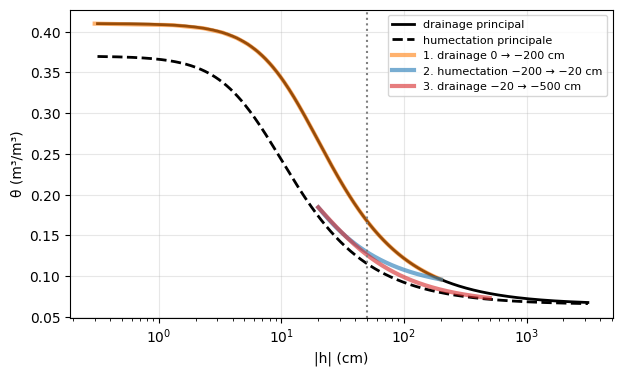

θ(h = -50 cm) sur drainage principal                  = 0.168
θ(h = -50 cm) sur humectation principale              = 0.115
θ(h = -50 cm) sur balayage humectation (branche 2)    = 0.129
θ(h = -50 cm) sur balayage drainage (branche 3)       = 0.126
Écart max entre branches : 0.052 m³/m³ (31 % de θ sur la courbe de drainage)


In [5]:
tr, ts_d, ad, n = 0.065, 0.41, 0.075, 1.89
aw, ts_w = 2 * ad, 0.37
m = 1 - 1 / n
Se_d = lambda h: (1 + (ad * np.abs(h)) ** n) ** (-m)
Se_w = lambda h: (1 + (aw * np.abs(h)) ** n) ** (-m)
theta_d = lambda h: tr + (ts_d - tr) * Se_d(h)
theta_w = lambda h: tr + (ts_w - tr) * Se_w(h)

def balayage_drainage(h, h_delta, theta_delta):
    """Courbe de balayage de drainage passant par (h_delta, theta_delta) : θs' ajusté, θr inchangé."""
    ts_p = tr + (theta_delta - tr) / Se_d(h_delta)
    return tr + (ts_p - tr) * Se_d(h)

def balayage_humectation(h, h_delta, theta_delta):
    """Courbe de balayage d'humectation passant par (h_delta, theta_delta) : θr' ajusté, θs^w inchangé."""
    tr_p = (theta_delta - ts_w * Se_w(h_delta)) / (1 - Se_w(h_delta))
    return tr_p + (ts_w - tr_p) * Se_w(h)

hh = -np.logspace(-0.5, 3.5, 400)
h1 = -np.linspace(0.3, 200, 200)                   # drainage principal 0 -> -200
th1 = theta_d(h1)
h2 = -np.linspace(200, 20, 200)                    # humectation -200 -> -20
th2 = balayage_humectation(h2, -200, th1[-1])
h3 = -np.linspace(20, 500, 300)                    # drainage -20 -> -500
th3 = balayage_drainage(h3, -20, th2[-1])

fig, ax = plt.subplots()
ax.semilogx(-hh, theta_d(hh), "k-", lw=2, label="drainage principal")
ax.semilogx(-hh, theta_w(hh), "k--", lw=2, label="humectation principale")
ax.semilogx(-h1, th1, color="C1", lw=3, alpha=0.6, label="1. drainage 0 → −200 cm")
ax.semilogx(-h2, th2, color="C0", lw=3, alpha=0.6, label="2. humectation −200 → −20 cm")
ax.semilogx(-h3, th3, color="C3", lw=3, alpha=0.6, label="3. drainage −20 → −500 cm")
ax.axvline(50, color="gray", ls=":")
ax.set_xlabel("|h| (cm)"); ax.set_ylabel("θ (m³/m³)"); ax.legend(fontsize=8); plt.show()

vals = {"drainage principal": theta_d(-50), "humectation principale": theta_w(-50),
        "balayage humectation (branche 2)": float(balayage_humectation(-50, -200, th1[-1])),
        "balayage drainage (branche 3)": float(balayage_drainage(-50, -20, th2[-1]))}
for k, v in vals.items():
    print(f"θ(h = -50 cm) sur {k:35s} = {v:.3f}")
print(f"Écart max entre branches : {max(vals.values()) - min(vals.values()):.3f} m³/m³ "
      f"({100 * (max(vals.values()) - min(vals.values())) / vals['drainage principal']:.0f} % de θ sur la courbe de drainage)")

**Commentaire (instructeur).** À $h = -50$ cm, $\theta$ vaut 0,17 sur la courbe de drainage principale mais seulement 0,12 sur la courbe d'humectation
principale ; les branches de balayage se placent entre les deux (0,13). Ignorer l'hystérésis (n'utiliser que la courbe de drainage,
comme la plupart des modèles) surestime $\theta$ de ~0,05 (30 %) en phase d'humectation : effet majeur pour un sol sableux, faible
pour une argile. Remarquer que la branche 3 (drainage depuis −20 cm) reste sous la courbe de drainage principale.

## Exercice 5 — Bonus — modèles de Kosugi et de Durner, critère AIC  *(≈ facultatif)*

Sur l'argile de l'exercice 1, ajuster le modèle de Kosugi (1996), $S_e = \tfrac12\,\mathrm{erfc}[\ln(|h|/h_m)/(\sqrt2\sigma)]$,
et le modèle bimodal de Durner (1994), $S_e = w\,[1+(\alpha_1|h|)^{n_1}]^{-m_1} + (1-w)\,[1+(\alpha_2|h|)^{n_2}]^{-m_2}$.
Comparer VG, Kosugi et Durner par le critère $\mathrm{AIC} = N\ln(\Phi/N) + 2k$ ($\Phi$ = somme des carrés des résidus,
$k$ = nombre de paramètres) et par sa version corrigée pour les petits échantillons, $\mathrm{AIC}_c = \mathrm{AIC} + 2k(k+1)/(N-k-1)$.
Le modèle bimodal est-il justifié avec 9 points ?

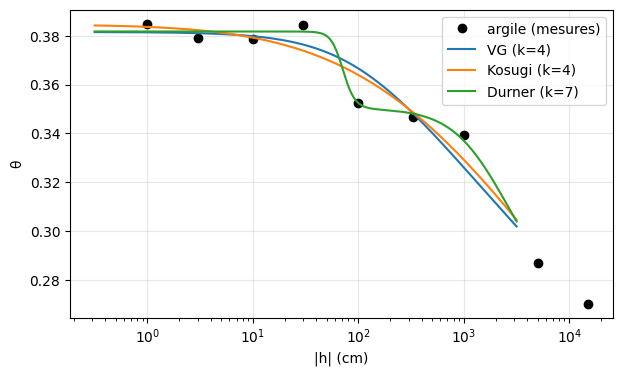

,RMSE,AIC,AICc
modele,,,
VG (k=4),0.0074,-80.2899,-70.2899
Kosugi (k=4),0.0068,-81.8045,-71.8045
Durner (k=7),0.0026,-93.2570,18.7430


In [6]:
def kosugi(h, tr, ts, hm, sig):
    return tr + (ts - tr) * 0.5 * special.erfc(np.log(np.abs(h) / hm) / (np.sqrt(2) * sig))

def durner(h, tr, ts, w, a1, n1, a2, n2):
    m1, m2 = 1 - 1 / n1, 1 - 1 / n2
    Se = w * (1 + (a1 * np.abs(h)) ** n1) ** (-m1) + (1 - w) * (1 + (a2 * np.abs(h)) ** n2) ** (-m2)
    return tr + (ts - tr) * Se

g = mes[mes["sol"] == "argile"]
h, th = g["h_cm"].to_numpy(), g["theta"].to_numpy()
N = h.size
modeles = {
    "VG (k=4)": (vg, [0.05, 0.4, 0.01, 1.2], ([0, 0.3, 1e-4, 1.05], [0.25, 0.6, 1, 8])),
    "Kosugi (k=4)": (kosugi, [0.05, 0.4, 500, 2.0], ([0, 0.3, 1, 0.2], [0.25, 0.6, 1e5, 6])),
    "Durner (k=7)": (durner, [0.05, 0.4, 0.3, 0.1, 2.0, 0.005, 1.3], ([0, 0.3, 0, 1e-3, 1.05, 1e-5, 1.05], [0.25, 0.6, 1, 1, 8, 0.1, 8])),
}
rows = []
fig, ax = plt.subplots()
ax.semilogx(-h, th, "ko", label="argile (mesures)")
for nom, (f, p0, bnd) in modeles.items():
    p, _ = optimize.curve_fit(f, h, th, p0=p0, bounds=bnd, maxfev=20000)
    Phi = np.sum((f(h, *p) - th) ** 2); k = len(p)
    aic = N * np.log(Phi / N) + 2 * k
    rows.append(dict(modele=nom, RMSE=np.sqrt(Phi / N), AIC=aic, AICc=aic + 2 * k * (k + 1) / (N - k - 1)))
    ax.semilogx(-hh, f(hh, *p), label=nom)
ax.set_xlabel("|h| (cm)"); ax.set_ylabel("θ"); ax.legend(); plt.show()
display(pd.DataFrame(rows).set_index("modele").round(4))

**Commentaire (instructeur).** Durner atteint un RMSE (0,003) inférieur au bruit des mesures (0,008) : surajustement. L'AIC brut le favorise pourtant, mais l'AICc (correction pour N petit : ici N − k − 1 = 1) le rejette massivement. Avec 9 points, seuls des modèles à 4 paramètres sont identifiables ; Kosugi et VG sont équivalents, Kosugi ayant l'avantage de paramètres à sens physique direct ($h_m$ = pression médiane des pores).

## Pour aller plus loin

* Exercice 1 : refaire l'ajustement en fixant $\theta_s$ à la valeur mesurée et $\theta_r = 0$ ; comparer les incertitudes sur $\alpha$ et $n$.
* Exercice 3 : ajouter la FPT HYPRES (Wösten et al., 1999) et comparer.
* Exercice 4 : implémenter la correction de Lenhard et al. (1991) contre le « pompage » sur plusieurs cycles successifs.